# ⚾ 매칭 사다리 정리: 재대결(메인)과 다음 타자(보조)를 나눠서 M0 → M3

* **작성자:** CY
* **작성일:** 2026-10-05
* **목적:** 장타 후 구종 회피가 경기 상황 때문은 아닌지, 그리고 장타를 친 타자에게만 나타나는지 바로 다음 타자에게도 나타나는지를 확인합니다. 지금까지는 점수 컬럼이 없어 점수차를 통제하지 못했고, 다음 타자 분석이 재대결 분석과 섞여 보고된 적이 있어 다음 세 가지를 한 노트북에서 정리합니다.
  1. **점수 차 확인:** M3(점수차 매칭)와 혼합모델 `score_diff` 공변량을 현재 데이터로 다시 실행
  2. **M0~M3 정리:** 단계별 표(유지율, SMD, 순수 감소, 오즈비)와 그래프
  3. **다음 타자와 재대결 분리:** 같은 사다리를 두 비교 기준에 각각 적용하고 결과를 따로 보고
* **두 비교 기준**
  * **재대결(메인, `same_batter`):** 장타를 친 타자의 같은 경기 다음 타석을 같은 투수가 상대한 경우
  * **다음 타자(보조, `next_batter`):** 같은 투수가 바로 다음 타석(`at_bat_number + 1`, 항상 다른 타자)을 상대한 경우
* **대조군:** `field_out`. 비교 타석이 있는 후보 중에서 단계별 칸(시즌×구종계열 → +주자·아웃 → +이닝·카운트 → +점수차)마다 장타와 같은 수를 뽑습니다.
* **순수 감소:** `(baseline − 비교 타석의 그 구종 비율)`의 장타 평균 − 대조군 평균. baseline은 시즌 구사율과 경기 내 직전까지 구사율 두 가지입니다.
* 상황 매칭 함수는 `notebooks/01_DY_situation_matched_control.ipynb`의 정의를 `src/analysis/situation_matching.py`로 옮긴 것입니다.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.mixed_effects_model import build_combined_model_dataset
from src.analysis.situation_matching import (
    LADDER_LABELS, LADDER_STEPS, MODES, RUNNER_LEVELS, SCORE_LEVELS,
    add_situation_columns, balance_table, build_step, build_xbh_events, pure_reduction,
    stratified_reduction, usable,
)
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

OUT_DIR = '../data/processed'
FIG_DIR = '../data/processed/figures'
os.makedirs(FIG_DIR, exist_ok=True)
MODE_LABELS = {'same_batter': '재대결 (메인)', 'next_batter': '다음 타자 (보조)'}

## 1. 데이터 읽기

`data/research/`의 팀 CSV 6개(점수 컬럼 포함)를 그대로 읽고 상황 변수를 붙입니다.

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score',
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year

assert len(pitches) == 3_592_302, len(pitches)
assert pitches['pitcher'].nunique() == 1_067
assert not pitches.duplicated(KEY_COLUMNS).any()
assert pitches[['home_score', 'away_score']].notna().all().all(), '점수 결측'

pitches = add_situation_columns(pitches)
season_usage = compute_season_usage_rate(pitches)
print(f'{len(pitches):,}행, 투수 {pitches["pitcher"].nunique():,}명')

3,592,302행, 투수 1,067명


## 2. 장타 이벤트와 단계별 대조군

두 비교 기준마다 장타 이벤트를 만들고, M0~M3 단계별로 대조군을 뽑습니다. 단계마다 칸별 장타 수와 대조군 수가 같도록 장타를 맞춥니다.
재대결 장타 건수는 기존 분석과 같아야 합니다(27,391건, 구종 있는 27,371건).

In [3]:
xbh_events, pairs, n_eligible = {}, {}, {}
for mode in MODES:
    xbh = build_xbh_events(pitches, season_usage, mode)
    xbh_events[mode] = xbh
    n_eligible[mode] = int(xbh['pitch_family'].notna().sum())
    print(f'[{MODE_LABELS[mode]}] 장타 {len(xbh):,}건 (구종 있는 {n_eligible[mode]:,}건)')
    for step in LADDER_STEPS:
        pairs[mode, step] = build_step(step, pitches, xbh, season_usage, mode)
        x, p = pairs[mode, step]
        print(f'  {step}: 장타 {len(x):,}건 유지 ({len(x) / n_eligible[mode]:.1%}), 대조군 {len(p):,}건')

assert len(xbh_events['same_batter']) == 27_391
assert n_eligible['same_batter'] == 27_371

[재대결 (메인)] 장타 27,391건 (구종 있는 27,371건)


  M0: 장타 27,371건 유지 (100.0%), 대조군 27,371건


  M1: 장타 27,348건 유지 (99.9%), 대조군 27,348건


  M2: 장타 27,156건 유지 (99.2%), 대조군 27,156건


  M3: 장타 26,816건 유지 (98.0%), 대조군 26,816건


[다음 타자 (보조)] 장타 66,052건 (구종 있는 66,017건)


  M0: 장타 66,017건 유지 (100.0%), 대조군 66,017건


  M1: 장타 46,103건 유지 (69.8%), 대조군 46,103건


  M2: 장타 45,868건 유지 (69.5%), 대조군 45,868건


  M3: 장타 45,374건 유지 (68.7%), 대조군 45,374건


## 3. 균형표 (SMD)

이벤트 시점 변수(주자·아웃·이닝·카운트·점수차·좌우)와 비교 타석 시점 변수(`*_next`)를 단계별로 비교합니다. |SMD| < 0.1이면 균형으로 봅니다.
매칭에 넣은 변수는 그 단계부터 0에 가까워져야 합니다.

In [4]:
BALANCE_COLUMNS = [
    'runners_n', 'risp', 'outs_when_up', 'inning', 'balls', 'strikes', 'score_diff', 'platoon_match',
    'runners_n_next', 'risp_next', 'score_diff_next',
]
balance = pd.concat({
    mode: pd.DataFrame({step: balance_table(*pairs[mode, step], BALANCE_COLUMNS)['smd'] for step in LADDER_STEPS})
    for mode in MODES
}, names=['mode', 'variable'])
display(balance.round(3))
balance.to_csv(f'{OUT_DIR}/ladder_balance_smd.csv')
for mode in MODES:
    b = balance.loc[mode]
    print(MODE_LABELS[mode], '|SMD| >= 0.1:', {s: b.index[b[s].abs() >= 0.1].tolist() for s in LADDER_STEPS})

M0     M1     M2     M3
mode        variable                                   
same_batter runners_n        0.124  0.000  0.000  0.000
            risp             0.029  0.000  0.000  0.000
            outs_when_up    -0.034  0.000  0.000  0.000
            inning          -0.045 -0.037 -0.031 -0.030
            balls            0.029  0.038 -0.037 -0.038
            strikes         -0.119 -0.104 -0.068 -0.064
            score_diff      -0.021 -0.025 -0.024 -0.001
            platoon_match   -0.056 -0.052 -0.041 -0.056
            runners_n_next  -0.003 -0.006 -0.010 -0.007
            risp_next       -0.000 -0.008 -0.009  0.000
            score_diff_next -0.439 -0.422 -0.424 -0.408
next_batter runners_n        0.335  0.000  0.000  0.000
            risp             0.214  0.000  0.000  0.000
            outs_when_up     0.684  0.000  0.000  0.000
            inning          -0.085 -0.077 -0.010 -0.012
            balls            0.034  0.030 -0.038 -0.034
            strikes         -0.124 -0.108 -0.066 -0.063
            score_diff      -0.054 -0.025 -0.012  0.005
            platoon_match   -0.063 -0.068 -0.065 -0.065
            runners_n_next   0.623  0.376  0.390  0.414
            risp_next        1.019  0.885  0.901  0.920
            score_diff_next -0.332 -0.270 -0.259 -0.237

재대결 (메인) |SMD| >= 0.1: {'M0': ['runners_n', 'strikes', 'score_diff_next'], 'M1': ['strikes', 'score_diff_next'], 'M2': ['score_diff_next'], 'M3': ['score_diff_next']}
다음 타자 (보조) |SMD| >= 0.1: {'M0': ['runners_n', 'risp', 'outs_when_up', 'strikes', 'runners_n_next', 'risp_next', 'score_diff_next'], 'M1': ['strikes', 'runners_n_next', 'risp_next', 'score_diff_next'], 'M2': ['runners_n_next', 'risp_next', 'score_diff_next'], 'M3': ['runners_n_next', 'risp_next', 'score_diff_next']}


## 4. 순수 감소와 재사용률

* `xbh_diff`, `placebo_diff`: 각 집단의 `baseline − 비교 타석 비율` 평균 (양수 = baseline보다 덜 던짐)
* `net`: 순수 감소 = `xbh_diff − placebo_diff`
* `reuse_xbh`, `reuse_placebo`: 비교 타석에서 그 구종을 한 번이라도 던진 비율

In [5]:
rows = []
for mode in MODES:
    for step in LADDER_STEPS:
        x, p = pairs[mode, step]
        row = {'mode': mode, 'step': step, 'n_xbh': len(x), 'n_placebo': len(p), 'retention': len(x) / n_eligible[mode]}
        for base, tag in [('season_usage_rate', 'season'), ('baseline_usage', 'game')]:
            r = pure_reduction(x, p, base)
            row.update({f'{tag}_{k}': v for k, v in r.items() if k not in ('n_xbh', 'n_placebo')})
        row['reuse_xbh'] = usable(x, 'season_usage_rate')['reused_same_type'].mean()
        row['reuse_placebo'] = usable(p, 'season_usage_rate')['reused_same_type'].mean()
        rows.append(row)
ladder = pd.DataFrame(rows).set_index(['mode', 'step'])
display(ladder.round(4))
ladder.to_csv(f'{OUT_DIR}/ladder_pure_reduction.csv')

m0 = ladder.loc[('same_batter', 'M0')]
assert 0.139 <= m0['season_net'] <= 0.151, m0['season_net']  # 기존 M0 14.39%p [13.94, 14.84] ~ 원본 14.6%p
print('재대결 M0가 기존 결과 범위 안에 있음')

n_xbh  n_placebo  retention  season_xbh_diff  season_placebo_diff  season_net  season_ci_low  season_ci_high  game_xbh_diff  game_placebo_diff  game_net  game_ci_low  game_ci_high  \
mode        step                                                                                                                                                                                        
same_batter M0    27371      27371     1.0000           0.1100              -0.0339      0.1439         0.1394          0.1484         0.1565             0.0030    0.1535       0.1484        0.1586   
            M1    27348      27348     0.9992           0.1099              -0.0350      0.1450         0.1405          0.1494         0.1565             0.0031    0.1534       0.1483        0.1585   
            M2    27156      27156     0.9921           0.1101              -0.0341      0.1441         0.1396          0.1486         0.1568             0.0053    0.1514       0.1463        0.1566   
            M3    26816      26816     0.9797           0.1102              -0.0333      0.1434         0.1389          0.1480         0.1571             0.0049    0.1521       0.1470        0.1573   
next_batter M0    66017      66017     1.0000           0.0612              -0.0068      0.0680         0.0650          0.0709         0.1003             0.0290    0.0713       0.0680        0.0746   
            M1    46103      46103     0.6984           0.0590              -0.0087      0.0677         0.0642          0.0712         0.0999             0.0264    0.0735       0.0695        0.0776   
            M2    45868      45868     0.6948           0.0589              -0.0095      0.0684         0.0649          0.0720         0.1000             0.0265    0.0734       0.0694        0.0775   
            M3    45374      45374     0.6873           0.0587              -0.0082      0.0669         0.0634          0.0704         0.1000             0.0282    0.0717       0.0677        0.0758   

                  reuse_xbh  reuse_placebo  
mode        step                            
same_batter M0       0.4552         0.6730  
            M1       0.4553         0.6821  
            M2       0.4557         0.6780  
            M3       0.4567         0.6770  
next_batter M0       0.5501         0.6551  
            M1       0.5508         0.6573  
            M2       0.5513         0.6577  
            M3       0.5519         0.6565

재대결 M0가 기존 결과 범위 안에 있음


## 5. 혼합효과 로지스틱 회귀 (R `lme4`)

* 공식: `reused_same_type ~ group * baseline_usage + balls + strikes + outs_when_up + score_diff + stand + pitch_family + factor(season) + (0 + group | pitcher)`
* `group` 오즈비가 1보다 작으면 장타 뒤 그 구종을 다시 던질 오즈가 대조군보다 낮다는 뜻입니다.
* R이 없으면 이 절은 건너뜁니다.

In [6]:
FORMULA = (
    'reused_same_type ~ group * baseline_usage + balls + strikes + outs_when_up + score_diff '
    '+ stand + pitch_family + factor(season) + (0 + group | pitcher)'
)
REQUIRED = [
    'reused_same_type', 'baseline_usage', 'balls', 'strikes', 'outs_when_up', 'score_diff',
    'stand', 'pitch_family', 'season', 'pitcher',
]
try:
    from src.analysis.glmer_runner import check_convergence, extract_fixed_effects_table, fit_glmer
    HAS_R = True
except Exception as e:  # rpy2/R 미설치
    HAS_R = False
    print('R을 쓸 수 없어 혼합모델을 건너뜁니다:', e)

mixed = None
if HAS_R:
    mrows = []
    for (mode, step), (x, p) in pairs.items():
        xf = x[x['has_next_ab'] & x['baseline_usage'].notna()]
        pf = p[p['has_next_ab'] & p['baseline_usage'].notna()]
        combined = build_combined_model_dataset(xf, pf, required_columns=REQUIRED)
        fit_glmer(combined, FORMULA)
        fe = extract_fixed_effects_table().set_index('term')
        mrows.append({
            'mode': mode, 'step': step, 'n_model': len(combined), 'convergence': check_convergence(),
            'group_or': fe.loc['group', 'odds_ratio'], 'group_or_low': fe.loc['group', 'or_ci_low'],
            'group_or_high': fe.loc['group', 'or_ci_high'],
            'inter_or': fe.loc['group:baseline_usage', 'odds_ratio'], 'inter_p': fe.loc['group:baseline_usage', 'p_value'],
            'score_diff_or': fe.loc['score_diff', 'odds_ratio'], 'score_diff_p': fe.loc['score_diff', 'p_value'],
        })
    mixed = pd.DataFrame(mrows).set_index(['mode', 'step'])
    display(mixed.round(4))
    mixed.to_csv(f'{OUT_DIR}/ladder_mixed_model.csv')

R callback write-console: 필요한 패키지를 로딩중입니다: Matrix
  


n_model                                    convergence  group_or  group_or_low  group_or_high  inter_or  inter_p  score_diff_or  score_diff_p
mode        step                                                                                                                                               
same_batter M0      53800  OK: no convergence warnings; isSingular=False    0.3039        0.2822         0.3273    1.7560   0.0000         0.9918        0.0778
            M1      53788  OK: no convergence warnings; isSingular=False    0.2815        0.2613         0.3032    1.9974   0.0000         0.9909        0.0482
            M2      53393  OK: no convergence warnings; isSingular=False    0.2925        0.2714         0.3151    1.8961   0.0000         0.9892        0.0222
            M3      52707  OK: no convergence warnings; isSingular=False    0.2892        0.2684         0.3117    2.0299   0.0000         0.9946        0.2564
next_batter M0     129153  OK: no convergence warnings; isSingular=False    0.5830        0.5550         0.6125    1.2625   0.0002         1.0031        0.1349
            M1      89970  OK: no convergence warnings; isSingular=False    0.6216        0.5877         0.6575    0.9884   0.8713         1.0044        0.0756
            M2      89591  OK: no convergence warnings; isSingular=False    0.6227        0.5886         0.6587    0.9838   0.8228         1.0014        0.5854
            M3      88536  OK: no convergence warnings; isSingular=False    0.6441        0.6085         0.6817    0.9111   0.2058         1.0058        0.0220

## 6. 상황별 층화 순수 감소 (M3, 시즌 baseline)

M3 표본 안에서 (a) 주자 상황, (b) 점수차 상황별로 나눠 순수 감소를 봅니다. 칸마다 양쪽 30건 미만이면 건너뜁니다.

In [7]:
strat = []
for mode in MODES:
    x, p = pairs[mode, 'M3']
    for col, levels in [('runner_group', RUNNER_LEVELS), ('score_diff_bucket', SCORE_LEVELS)]:
        r = stratified_reduction(x, p, 'season_usage_rate', col, levels).rename(columns={col: 'level'})
        strat.append(r.assign(mode=mode, by=col))
strat = pd.concat(strat, ignore_index=True)[['mode', 'by', 'level', 'n_xbh', 'n_placebo', 'net', 'ci_low', 'ci_high']]
display(strat.round(4))
strat.to_csv(f'{OUT_DIR}/ladder_stratified_m3.csv', index=False)

,mode,by,level,n_xbh,n_placebo,net,ci_low,ci_high
0,same_batter,runner_group,주자 없음,17197,17197,0.1427,0.1371,0.1484
1,same_batter,runner_group,1루만,5005,5005,0.1364,0.1259,0.1468
2,same_batter,runner_group,득점권,4614,4614,0.1538,0.1429,0.1647
3,same_batter,score_diff_bucket,뒤짐,6576,6576,0.1451,0.1360,0.1542
4,same_batter,score_diff_bucket,동점,12498,12498,0.1376,0.1310,0.1442
5,same_batter,score_diff_bucket,앞섬,7742,7742,0.1515,0.1430,0.1600
6,next_batter,runner_group,주자 없음,29807,29807,0.0623,0.0580,0.0666
7,next_batter,runner_group,1루만,8173,8173,0.0746,0.0662,0.0830
8,next_batter,runner_group,득점권,7394,7394,0.0768,0.0679,0.0857
9,next_batter,score_diff_bucket,뒤짐,14971,14971,0.0692,0.0631,0.0753


## 7. 그래프

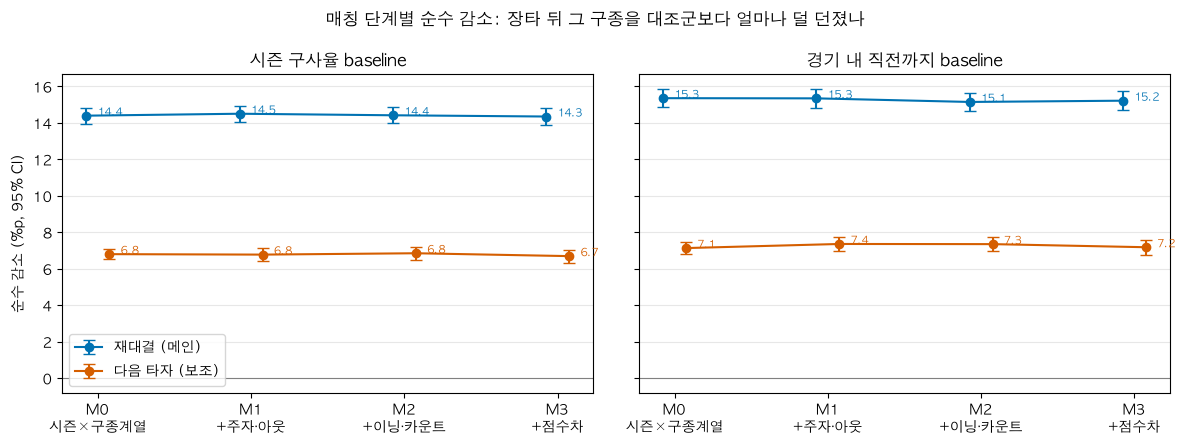

In [8]:
steps = list(LADDER_STEPS)
xs = np.arange(len(steps))
colors = {'same_batter': '#0072B2', 'next_batter': '#D55E00'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (tag, title) in zip(axes, [('season', '시즌 구사율 baseline'), ('game', '경기 내 직전까지 baseline')]):
    for i, mode in enumerate(MODES):
        d = ladder.loc[mode]
        y = d[f'{tag}_net'] * 100
        err = np.vstack([y - d[f'{tag}_ci_low'] * 100, d[f'{tag}_ci_high'] * 100 - y])
        ax.errorbar(xs + (i - 0.5) * 0.15, y, yerr=err, fmt='o-', capsize=4, color=colors[mode], label=MODE_LABELS[mode])
        for xi, yi in zip(xs + (i - 0.5) * 0.15, y):
            ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(8, 0), fontsize=8, color=colors[mode])
    ax.set_xticks(xs, [f'{s}\n{LADDER_LABELS[s]}' for s in steps])
    ax.set_title(title)
    ax.axhline(0, color='grey', lw=0.8)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('순수 감소 (%p, 95% CI)')
axes[0].legend()
fig.suptitle('매칭 단계별 순수 감소: 장타 뒤 그 구종을 대조군보다 얼마나 덜 던졌나')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ladder_pure_reduction.png', dpi=150)
plt.show()

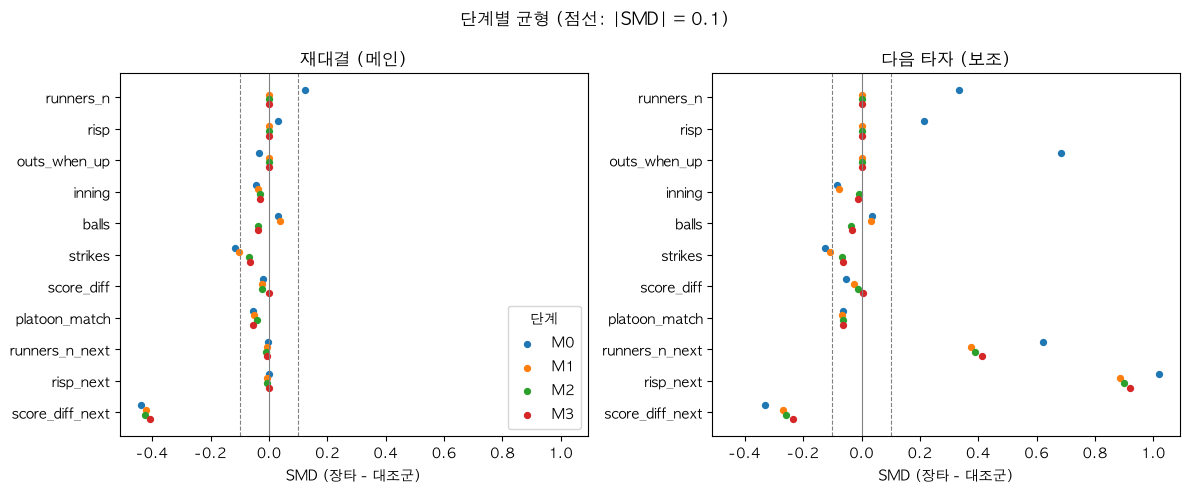

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ax, mode in zip(axes, MODES):
    b = balance.loc[mode]
    for j, step in enumerate(steps):
        ax.scatter(b[step], np.arange(len(b)) + (j - 1.5) * 0.15, s=18, label=step)
    ax.axvline(0, color='grey', lw=0.8)
    for v in (-0.1, 0.1):
        ax.axvline(v, color='grey', lw=0.8, ls='--')
    ax.set_yticks(np.arange(len(b)), b.index)
    ax.invert_yaxis()
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('SMD (장타 - 대조군)')
axes[0].legend(title='단계', loc='lower right')
fig.suptitle('단계별 균형 (점선: |SMD| = 0.1)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ladder_balance_smd.png', dpi=150)
plt.show()

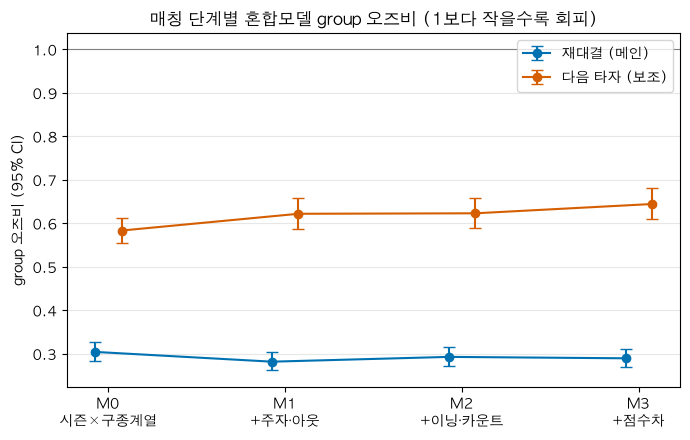

In [10]:
if mixed is not None:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, mode in enumerate(MODES):
        d = mixed.loc[mode]
        y = d['group_or']
        err = np.vstack([y - d['group_or_low'], d['group_or_high'] - y])
        ax.errorbar(xs + (i - 0.5) * 0.15, y, yerr=err, fmt='o-', capsize=4, color=colors[mode], label=MODE_LABELS[mode])
    ax.axhline(1, color='grey', lw=0.8)
    ax.set_xticks(xs, [f'{s}\n{LADDER_LABELS[s]}' for s in steps])
    ax.set_ylabel('group 오즈비 (95% CI)')
    ax.set_title('매칭 단계별 혼합모델 group 오즈비 (1보다 작을수록 회피)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/ladder_group_odds_ratio.png', dpi=150)
    plt.show()

## 8. 해석

### 재대결 (메인)

* **기존 결과를 그대로 재현했습니다.** 장타 27,391건(구종 있는 27,371건), M0~M3 순수 감소와 오즈비가 `notebooks/01_DY_situation_matched_control.ipynb`와 소수점까지 같습니다. 상황 매칭 함수를 `src/`로 옮겨도 결과가 바뀌지 않았습니다.
* **점수 차를 맞춰도 회피가 남습니다.** 시즌 baseline 순수 감소는 M0 14.39%p → M1 14.50 → M2 14.41 → **M3 14.34%p** [13.89, 14.80], 경기 내 baseline은 15.35 → 15.34 → 15.14 → 15.21%p입니다. 모든 변화가 M0 신뢰구간(약 ±0.5%p) 안입니다.
* **오즈비도 같습니다.** `group` 오즈비 0.304 → 0.282 → 0.293 → **0.289** [0.268, 0.312]. 장타 뒤 그 구종을 재대결에서 다시 던질 오즈가 대조군의 약 30%입니다. `group × baseline_usage` 오즈비는 1.76~2.03으로, 평소 그 구종 의존도가 높을수록 덜 피합니다(대체 구종이 마땅치 않음).
* **점수차 공변량 자체의 효과는 작습니다.** `score_diff` 오즈비 0.989~0.995. M0에서 이미 이벤트 시점 점수차가 거의 균형(SMD −0.021)이었기 때문입니다.
* **균형:** 매칭 변수는 넣은 단계부터 SMD 0이 됩니다. M2부터는 이벤트 시점 변수 전부 |SMD| < 0.1입니다. 남는 불균형은 `score_diff_next`(−0.41) 하나인데, 장타가 점수를 바꾸는 사건이라 생기는 당연한 차이입니다(매칭으로 없앨 대상이 아님).
* **상황별로도 같습니다(M3).** 주자 없음 14.3, 1루만 13.6, 득점권 15.4%p / 뒤짐 14.5, 동점 13.8, 앞섬 15.2%p. 신뢰구간이 서로 겹쳐 위기 상황에서 효과가 달라진다는 증거는 없습니다.

### 다음 타자 (보조)

* **회피는 있지만 재대결의 절반 이하입니다.** 시즌 baseline 순수 감소 M0 6.80%p → **M3 6.69%p** [6.34, 7.04], `group` 오즈비 0.583 → **0.644** [0.609, 0.682].
* **⚠️ M1부터 장타의 30%가 빠집니다(유지율 69.8%).** 2아웃 상황의 `field_out`은 이닝을 끝내서 같은 투수의 다음 타석이 구조적으로 없습니다(비교 타석이 있는 `field_out` 중 2아웃은 0건). 그래서 2아웃 장타(전체의 30.2%)는 짝이 될 대조군이 없어 M1부터 빠집니다. M0에서 아웃카운트 SMD가 0.684로 컸던 이유도 이것입니다. **다음 타자 결과는 0·1아웃 장타에만 해당합니다.**
* **비교 타석의 상황이 크게 다릅니다.** 장타 직후 다음 타자는 주자가 득점권에 있는 경우가 훨씬 많습니다(`risp_next` SMD 0.92, `runners_n_next` 0.41). 이것도 장타의 결과라 매칭으로 없앨 수 없지만, 득점권에서는 투수가 원래 배합을 바꾸므로 **다음 타자 분석의 회피에는 "다음 타석이 위기라서"가 섞여 있을 수 있습니다.** 재대결은 비교 타석 상황이 균형이라(`risp_next` SMD 0.000) 이 문제가 없습니다. 메인을 재대결로 두는 근거입니다.
* **의존도와의 상호작용이 사라집니다.** `group × baseline_usage` 오즈비가 M0 1.26(p = 0.0002)에서 M1~M3 0.91~0.99(p > 0.2)로 바뀝니다. 2아웃 장타를 빼면 이 상호작용은 남지 않습니다.

### 결론

* **재대결에서 장타 후 구종 회피는 주자·아웃·이닝·카운트·점수차를 모두 맞춰도 약 14%p(오즈비 약 0.29)로 남습니다.**
* 다음 타자에서도 회피가 보이지만 크기가 절반 이하이고, 2아웃이 빠지며, 비교 타석 상황이 달라 해석에 주의가 필요합니다. 그래서 두 분석을 따로 보고합니다.

### 한계

* 레버리지, 투수 피로·압박 같은 관측하지 않은 요인은 배제하지 못했습니다.
* 주자·점수차는 투구 직전 상태입니다.
* 다음 타자 기준은 0·1아웃 장타로만 대조군 비교가 가능합니다.